# CSC 555 - Final Project Local Build

Connor Stefanovich

11/15/2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [2]:
#%pip install xgboost

In [3]:
# Import data
df = pd.read_csv("Data/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_7.csv")

C:\Users\emma\AppData\Local\Temp\ipykernel_13088\2245714512.py:2: DtypeWarning: Columns (77,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Data/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_7.csv")


# Data Cleaning

In [4]:
# Select only relevant columns
columns_to_keep = [
    "DayofMonth", "Month", "DayOfWeek", 
    "Reporting_Airline", "Origin", "Dest", 
    "CRSDepTime", "DepDelay", "DepDel15",
    "Cancelled", "CRSElapsedTime", "Distance", 
    "CarrierDelay", "WeatherDelay", "NASDelay", 
    "SecurityDelay", "LateAircraftDelay"
]
df = df[columns_to_keep]

In [5]:
# Inspect original data
print(df.head())
print(df.dtypes)
print(f"Total rows before cleaning: {len(df)}")

   DayofMonth  Month  DayOfWeek Reporting_Airline Origin Dest  CRSDepTime  \
0          23      7          3                AA    MIA  CLT         832   
1          24      7          4                AA    MIA  CLT         832   
2          25      7          5                AA    MIA  CLT         832   
3          26      7          6                AA    MIA  CLT         832   
4          27      7          7                AA    MIA  CLT         832   

   DepDelay  DepDel15  Cancelled  CRSElapsedTime  Distance  CarrierDelay  \
0      -3.0       0.0        0.0           130.0     650.0           NaN   
1      85.0       1.0        0.0           130.0     650.0           0.0   
2      -4.0       0.0        0.0           130.0     650.0           NaN   
3      -5.0       0.0        0.0           130.0     650.0           NaN   
4       4.0       0.0        0.0           130.0     650.0           NaN   

   WeatherDelay  NASDelay  SecurityDelay  LateAircraftDelay  
0           NaN   

In [6]:
# Filter for flights originating from ORD
df = df[df["Origin"] == "ORD"]
df = df.drop("Origin", axis = 1)

# Remove cancelled flights
df = df[df["Cancelled"] != 1]
df = df.drop("Cancelled", axis = 1)

# Convert CRSDepTime from HHMM time format to minutes since midnight
df["CRSDepTime"] = (df["CRSDepTime"] // 100) * 60 + (df["CRSDepTime"] % 100)

# Convert delay type measurement columns to binary event indicators
delay_columns = ["CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]
for col in delay_columns:
    df[col] = np.where(df[col] > 0, 1, 0)

In [7]:
# Inspect cleaned data
print(df.head())
print(df.dtypes)
print(f"Total rows after cleaning: {len(df)}")

    DayofMonth  Month  DayOfWeek Reporting_Airline Dest  CRSDepTime  DepDelay  \
89           2      7          3                AA  LGA        1225      -7.0   
90           3      7          4                AA  LGA        1225     654.0   
91           4      7          5                AA  LGA        1140       1.0   
92           5      7          6                AA  LGA        1225      12.0   
93           6      7          7                AA  LGA        1225     167.0   

    DepDel15  CRSElapsedTime  Distance  CarrierDelay  WeatherDelay  NASDelay  \
89       0.0           140.0     733.0             0             0         0   
90       1.0           140.0     733.0             1             0         0   
91       0.0           140.0     733.0             0             0         0   
92       0.0           139.0     733.0             0             0         0   
93       1.0           139.0     733.0             1             0         0   

    SecurityDelay  LateAircraftD

# EDA

In [8]:
# Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29711 entries, 89 to 631157
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DayofMonth         29711 non-null  int64  
 1   Month              29711 non-null  int64  
 2   DayOfWeek          29711 non-null  int64  
 3   Reporting_Airline  29711 non-null  object 
 4   Dest               29711 non-null  object 
 5   CRSDepTime         29711 non-null  int64  
 6   DepDelay           29711 non-null  float64
 7   DepDel15           29711 non-null  float64
 8   CRSElapsedTime     29711 non-null  float64
 9   Distance           29711 non-null  float64
 10  CarrierDelay       29711 non-null  int64  
 11  WeatherDelay       29711 non-null  int64  
 12  NASDelay           29711 non-null  int64  
 13  SecurityDelay      29711 non-null  int64  
 14  LateAircraftDelay  29711 non-null  int64  
dtypes: float64(4), int64(9), object(2)
memory usage: 3.6+ MB
None


In [10]:
# Check summary of numeric variables
print(df.describe())

         DayofMonth    Month     DayOfWeek    CRSDepTime      DepDelay  \
count  29711.000000  29711.0  29711.000000  29711.000000  29711.000000   
mean      16.285282      7.0      3.882064    834.144290     28.744202   
std        8.894891      0.0      1.955021    286.782333     74.613891   
min        1.000000      7.0      1.000000     59.000000    -40.000000   
25%        9.000000      7.0      2.000000    581.000000     -4.000000   
50%       17.000000      7.0      4.000000    835.000000      2.000000   
75%       24.000000      7.0      6.000000   1094.000000     32.000000   
max       31.000000      7.0      7.000000   1369.000000   2364.000000   

           DepDel15  CRSElapsedTime      Distance  CarrierDelay  WeatherDelay  \
count  29711.000000    29711.000000  29711.000000  29711.000000  29711.000000   
mean       0.354650      143.959106    753.085288      0.196796      0.032648   
std        0.478415       65.787182    523.135846      0.397583      0.177716   
min      

<Figure size 1200x1600 with 0 Axes>

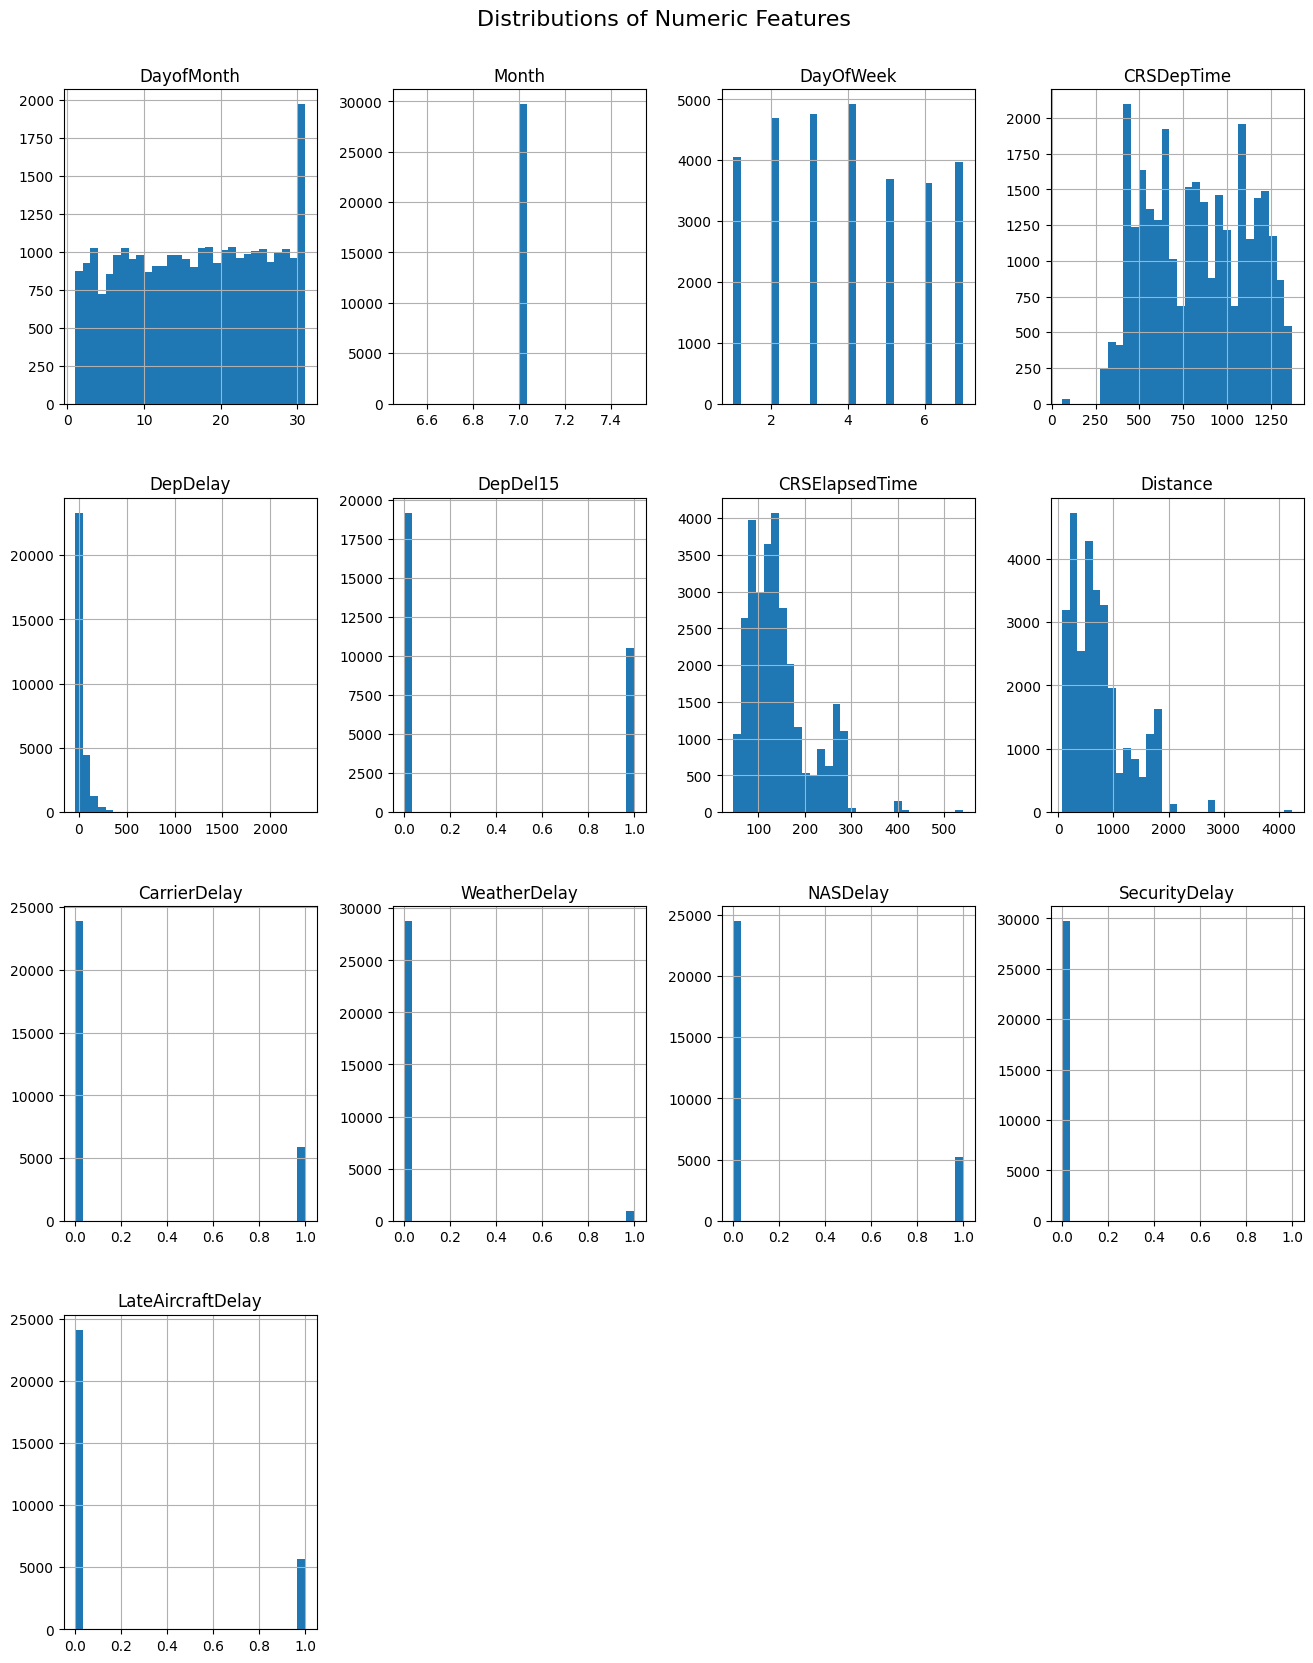

In [15]:
# Numeric variable distributions
numeric_cols = df.select_dtypes(include = np.number).columns.tolist()

plt.figure(figsize = (12, 16))
df[numeric_cols].hist(bins = 30, figsize = (16, 20))
plt.suptitle("Distributions of Numeric Features", y = 0.92, fontsize = 16)
plt.show()


========== CLASS BALANCE (DepDel15) ==========
DepDel15
0.0    19174
1.0    10537
Name: count, dtype: int64
DepDel15
0.0    0.64535
1.0    0.35465
Name: proportion, dtype: float64


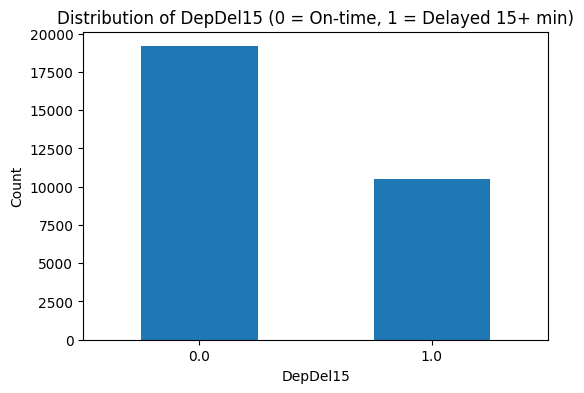

In [18]:
# Check target variable for class imbalance
print("\n========== CLASS BALANCE (DepDel15) ==========")
print(df["DepDel15"].value_counts())
print(df["DepDel15"].value_counts(normalize = True))

plt.figure(figsize = (6, 4))
df["DepDel15"].value_counts().plot(kind = "bar")
plt.title("Distribution of DepDel15 (0 = On-time, 1 = Delayed 15+ min)")
plt.xlabel("DepDel15")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

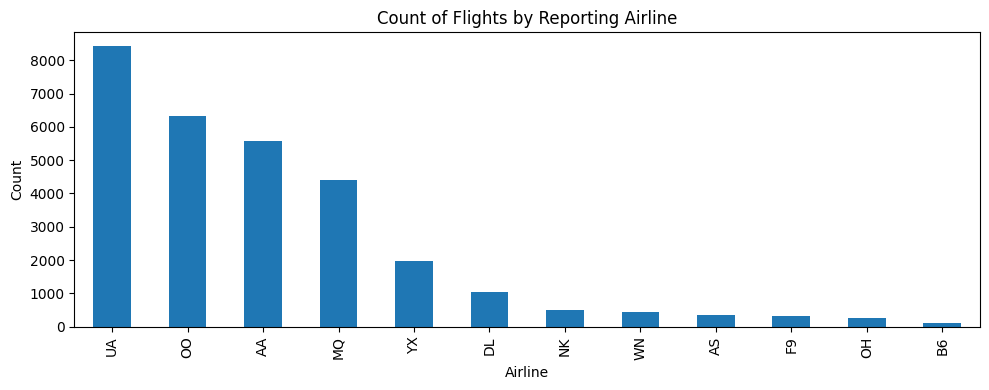

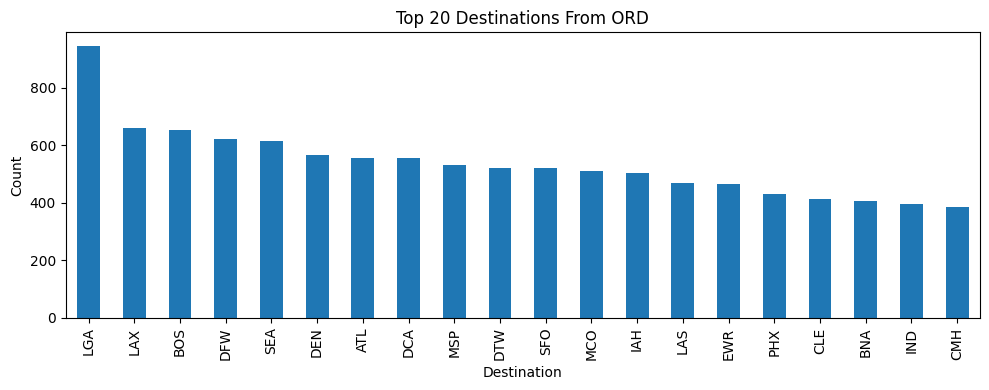

In [17]:
# Categorical feature analysis

# Airline frequency
plt.figure(figsize = (10, 4))
df["Reporting_Airline"].value_counts().plot(kind = "bar")
plt.title("Count of Flights by Reporting Airline")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Destination frequency BEFORE simplifying to top 10 + Other
plt.figure(figsize = (10, 4))
df["Dest"].value_counts().nlargest(20).plot(kind = "bar")
plt.title("Top 20 Destinations From ORD")
plt.xlabel("Destination")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

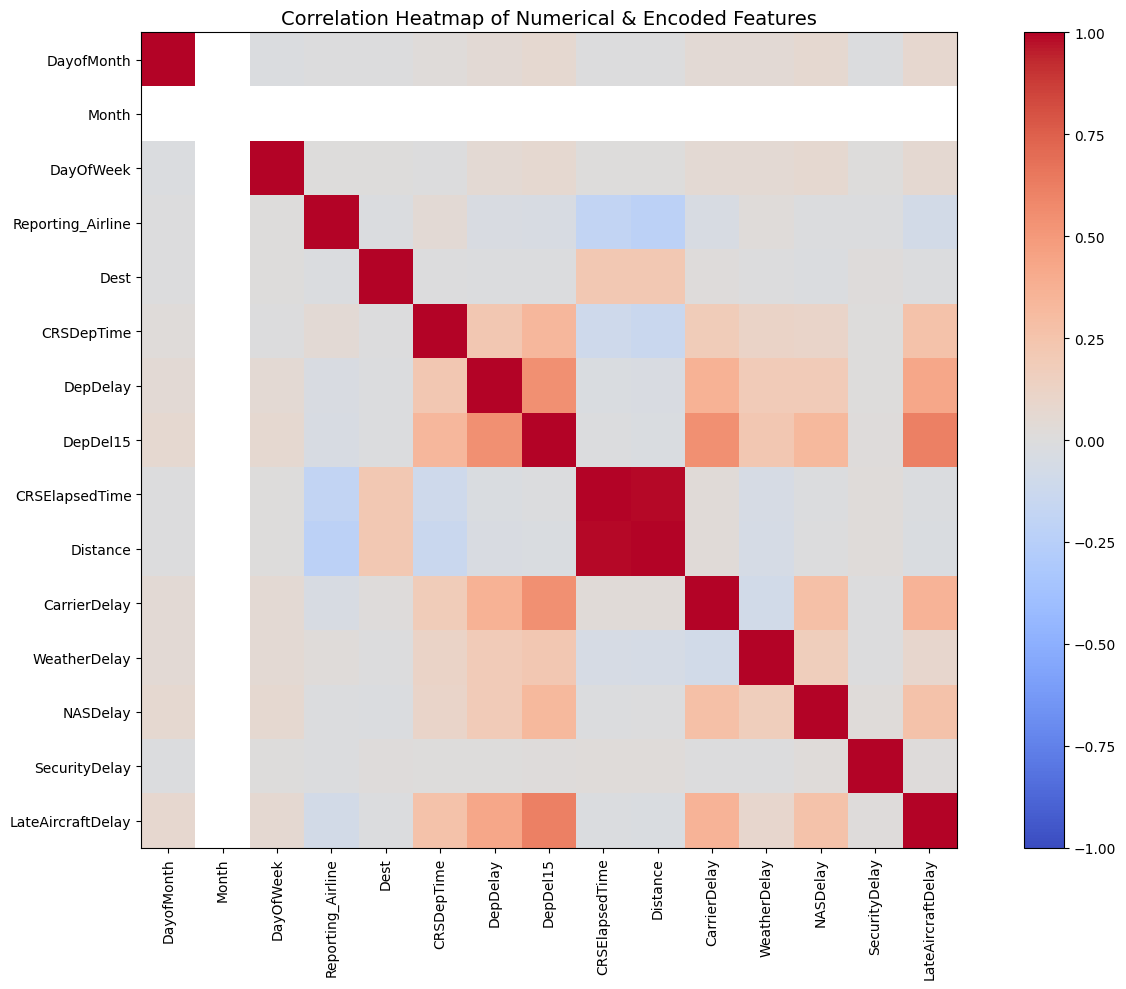


========== CORRELATION MATRIX (first 10 columns) ==========
                   DayofMonth  Month  DayOfWeek  Reporting_Airline   Dest  \
DayofMonth              1.000    NaN     -0.017             -0.005 -0.001   
Month                     NaN    NaN        NaN                NaN    NaN   
DayOfWeek              -0.017    NaN      1.000              0.003  0.001   
Reporting_Airline      -0.005    NaN      0.003              1.000 -0.021   
Dest                   -0.001    NaN      0.001             -0.021  1.000   
CRSDepTime              0.022    NaN     -0.004              0.046 -0.006   
DepDelay                0.040    NaN      0.052             -0.034 -0.008   
DepDel15                0.066    NaN      0.069             -0.044 -0.010   
CRSElapsedTime         -0.004    NaN      0.006             -0.187  0.212   
Distance               -0.007    NaN      0.006             -0.220  0.214   

                   CRSDepTime  DepDelay  DepDel15  CRSElapsedTime  Distance  
DayofMonth   

In [19]:
# Correlation matrix

# Compute correlation BEFORE one-hot encoding (otherwise the heatmap has too many columns)
df_for_corr = df.copy()

# Encode categorical columns temporarily as integer categories
df_for_corr["Reporting_Airline"] = df_for_corr["Reporting_Airline"].astype("category").cat.codes
df_for_corr["Dest"] = df_for_corr["Dest"].astype("category").cat.codes

corr_matrix = df_for_corr.corr(numeric_only = True)

plt.figure(figsize = (14, 10))
plt.imshow(corr_matrix, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation = 90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Numeric & Encoded Features", fontsize = 14)
plt.tight_layout()
plt.show()

print("\n========== CORRELATION MATRIX (first 10 columns) ==========")
print(corr_matrix.round(3).iloc[:10, :10])

# ML Data Prep

In [12]:
# Simplify destinations for encoding - only 10 most frequent destinations
top_dest = df["Dest"].value_counts().nlargest(10).index
df["Dest"] = df["Dest"].apply(lambda x: x if x in top_dest else "Other")

# One-hot encoding for Reporting_Airline and Dest
df = pd.get_dummies(df, columns = ["Reporting_Airline", "Dest"], drop_first = True, dtype = "int")

print(df.head())

# Modelling

## Logistic Regression Model

In [14]:
# Train/test split
X = df.drop(["DepDel15", "DepDelay"], axis = 1)
y = df["DepDel15"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123, stratify = y)

In [15]:
# Logistic regression
logreg = LogisticRegression(
    class_weight = 'balanced',
    C = 0.5,
    max_iter = 10000,
    solver = "lbfgs"
)

# Fit and predict
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]  # probability of class 1

In [16]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

Accuracy:  0.8980
Precision: 0.9068
Recall:    0.7941
ROC AUC:   0.9270


[[3663  172]
 [ 434 1674]]


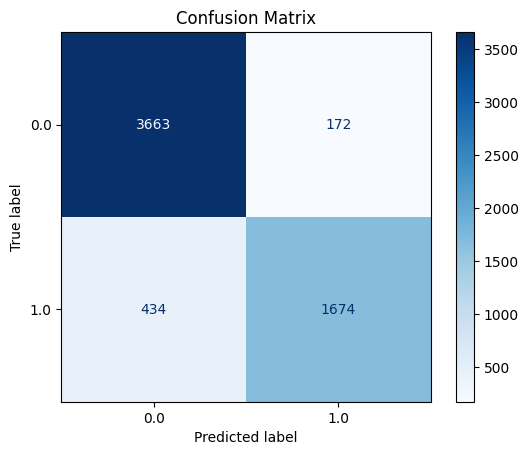

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = logreg.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

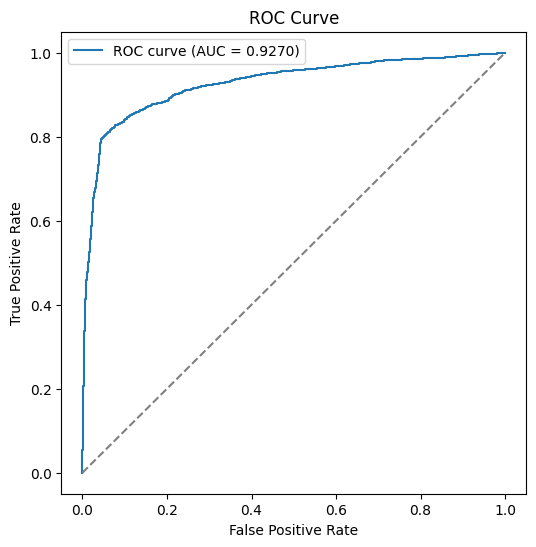

In [18]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize = (6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle = '--', color = 'gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [19]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logreg.coef_[0]
})

feature_importance['Abs_Coeff'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by = 'Abs_Coeff', ascending = False)

print("Feature importance:")
print(feature_importance)

Feature importance:
                 Feature  Coefficient  Abs_Coeff
10     LateAircraftDelay     4.258037   4.258037
7           WeatherDelay     4.008582   4.008582
6           CarrierDelay     3.311867   3.311867
31              Dest_SEA    -0.837018   0.837018
21  Reporting_Airline_YX    -0.805957   0.805957
15  Reporting_Airline_MQ    -0.765390   0.765390
1                  Month    -0.652873   0.652873
17  Reporting_Airline_OH    -0.621573   0.621573
22              Dest_BOS     0.592170   0.592170
11  Reporting_Airline_AS     0.450020   0.450020
18  Reporting_Airline_OO    -0.436269   0.436269
23              Dest_DCA     0.425417   0.425417
26              Dest_DTW    -0.414415   0.414415
28              Dest_LGA     0.367590   0.367590
19  Reporting_Airline_UA    -0.363261   0.363261
8               NASDelay     0.357415   0.357415
16  Reporting_Airline_NK     0.315377   0.315377
14  Reporting_Airline_F9    -0.202843   0.202843
13  Reporting_Airline_DL    -0.180196   0.180196


The results of this model are good. 
- Accuracy: Nearly 90% of flights were correctly classified as delayed or not.
- Precision: Of all the flights predicted as delayed, about 91% were actually delayed. Good for minimizing false alarms.
- Recall: The model catches about 79% of actual delays. There is some room to improve detecting all delayed flights.
- ROC AUC: Excellent discrimination, the model is very good at distinguishing delayed vs non-delayed flights.
- Feature importances: The most influential features are the delay event indicators (except for SecurityDelay), followed by certain destinations and airlines.

## XGBoost Model

In [20]:
# Train/test split
X = df.drop(["DepDel15", "DepDelay"], axis = 1)
y = df["DepDelay"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)

In [21]:
# XGBoost model
xgb = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 8,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = 'reg:squarederror',
    n_jobs = -1,
    random_state = 123
)

# Fit and predict
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {round(mae, 3)}")
print(f"RMSE: {round(rmse, 3)}")
print(f"R^2:  {round(r2, 4)}")

# Feature Importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending = False)

print("\nFeature importance:")
print(importance)

MAE:  23.306
RMSE: 58.484
R^2:  0.212

Feature importance:
                 Feature  Importance
10     LateAircraftDelay    0.108910
12  Reporting_Airline_B6    0.081514
6           CarrierDelay    0.072563
17  Reporting_Airline_OH    0.069852
7           WeatherDelay    0.063450
14  Reporting_Airline_F9    0.043448
13  Reporting_Airline_DL    0.035696
23              Dest_DCA    0.034303
18  Reporting_Airline_OO    0.032860
15  Reporting_Airline_MQ    0.031733
25              Dest_DFW    0.031479
8               NASDelay    0.029744
31              Dest_SEA    0.028963
19  Reporting_Airline_UA    0.027186
28              Dest_LGA    0.025431
11  Reporting_Airline_AS    0.022152
0             DayofMonth    0.021849
4         CRSElapsedTime    0.021610
3             CRSDepTime    0.021310
5               Distance    0.021284
27              Dest_LAX    0.020943
26              Dest_DTW    0.020931
16  Reporting_Airline_NK    0.020381
30            Dest_Other    0.020295
24              

The results of this model are mediocre. This could be due to the fact that the dataset is just one month's worth of flight data.
- MAE (mean absolute error): On average, predictions are off by about 23 minutes.
- RMSE (root mean square error): The RMSE is higher than MAE, showing there are some large outlier delays that the model struggles to predict.
- R^2: Only about 21% of the variance in delay minutes is explained. This might indicate overfitting on certain patterns or that the non-linear effects are subtle in this one-month dataset.